
# Officer of the Watch (OOW) Agent — From COLREG Text to Agentic Training Data
## Auto Pilot Project · OOW Module

This notebook is the **OOW analogue of `VHF_Agent_Training_Pipeline.ipynb`**: same pipeline shape
(§0 setup → §1 eval data → §2 JSON → §3 RAG → §4 KG → §5 reasoning traces → §6 SFT/DPO/reflection →
§7 gold-claims → §8 Procedural Graph → §9 metrics explained → §10 baseline → §11 ablation → §12
quality gates → §13 fine-tune/merge/eval → §14 compression → §15 final comparison), pointed at a
different domain via `AUTOPILOT_DOMAIN=OOW` instead of hardcoding a second copy of every script.

### What the OOW agent is (see `Docs/Multi-Agent_Maritime_Navigation_System_Architecture_Plan rev JS v4.pdf`)

In the multi-agent ship's-bridge architecture, the **Officer of the Watch (= "Navigation Agent")**:
- receives parsed contact tracks from the **Perception/Lookout agent** (bearing, range, CPA/TCPA,
  encounter type) and own-ship position/state from the **Localization/Quartermaster agent** — both in
  natural language, not raw sensor data;
- runs pathfinding (A*/DWA) and **strictly applies COLREG** to decide the collision-avoidance action;
- outputs a **human-style helm + engine order** ("30 degrees port", "50 degrees starboard", "1 degree
  port"; engine "full ahead" / "full back" / "continue course") — **not** a raw MOOS `DESIRED_HEADING`/
  `DESIRED_SPEED` call. Translating that order into an exact rudder angle/RPM is the job of a separate,
  later **Actuator Agent (Helmsman)**, per the architecture doc's own phasing.
- Per the architecture doc §8 ("Language Models" / data-per-agent table): the Navigation Agent is
  fine-tuned on **COLREG + maritime training handbooks**; the Actuator/Perception/Localization agents
  need **no fine-tuning** (interface/translation layers only) — so this notebook is the one place real
  training work happens for this whole sub-tree.

### Learning goals
- Reuse the *exact same* generic pipeline scripts as VHF (`pipeline/ingest`, `pipeline/track1`,
  `pipeline/train`, `pipeline/eval`, `pipeline/compress`), selected via the `AUTOPILOT_DOMAIN` env var
  (`core.AgentPaths.from_env()`), rather than forking a parallel copy of every script.
- Understand why COLREG's Track 1 (rules & knowledge) is fully built here, while Track 2 (applied
  helm/engine-order decision-making) is deliberately scoped as **Phase 2** (see §6.5 below) —
  analogous to how VHF's Track 2 (conversational compliance) was built as a second pass after Track 1
  was working end-to-end.


## Two tracks, from day one

| | Track 1 — COLREG rules & knowledge | Track 2 — Applied helm/engine-order decisions |
|---|---|---|
| Eval data (held out, NEVER used for training) | `Data/OOW/OOW_Eval/colreg_qa_500.json` (500 Q&A) | *(planned)* scenario → helm/engine-order pairs derived from the existing 12 MOOS scenario geometries (`generate_moos_scenarios.py` / `scenarios_manifest.json`) |
| Training data | `oow_sft_direct/cot/rag.jsonl`, `oow_multihop.jsonl`, `oow_dpo_pairs.jsonl`, `oow_reflection.jsonl`, `oow_pg_sft.jsonl` | *(Phase 2 — not yet built, see §6.5)* |
| Eval script | `pipeline/eval/eval_finetuned.py --gold-file colreg_qa_500_normalised.json` | *(Phase 2)* |

Both tracks would feed the **same** QLoRA fine-tune, exactly like VHF's `train_sft.py`/`train_dpo.py`/
`train_reflection.py` load a list of files spanning both tracks — but this notebook only builds
Track 1 end-to-end for now. Track 2 needs its own scenario/category design (analogous to
`pipeline/track2/build_vhf_colreg_scenarios.py`) before it can be generated; see §6.5 for the
concrete plan.


## Repository layout — where OOW data & models live

```
Data/OOW/                          ← AgentPaths.oow().data_root
├── OOW_Protocols/                 ← source_dir   (training documents: COLREG-Consolidated-2018.pdf, ...)
├── OOW_Eval/                      ← eval_dir     (held-out evaluation)
│   └── colreg_qa_500.json         ← gold Q&A (500 items) — NOT the default oow_gold_answers.json name,
│                                     loaded explicitly via --gold-file everywhere in this notebook
├── OOW_JSON/                      ← json_dir     (§ 8 output)
├── OOW_Agents_Training/           ← cache_dir    (RAG/KG/traces/SFT/DPO/reflection)
├── OOW_Literature_Review/         ← background research (not a pipeline input)
└── OOW_MOOS_Integration/          ← colreg_llm_bridge.py + MOOS scenario/eval scaffolding (Track 2 input, later)
_models/OOW/                       ← domain_models_dir (adapters + merged OOW-QWEN)
```

This mirrors VHF's layout exactly (see that notebook's own "Repository layout" section) — only the
`Data/<domain>` segment and the two domain-specific filenames (`OOW_Protocols`, `colreg_qa_500.json`)
differ. Every path below comes from `AgentPaths.oow()` (equivalently, `AgentPaths.from_env()` with
`AUTOPILOT_DOMAIN=OOW`) — never hardcoded — so this notebook and the shared pipeline scripts can never
silently diverge on where things live.

---
## § 0 — Environment Setup

Same dependency set as the VHF notebook (this is a workspace-wide `.venv`, not domain-scoped) — safe to
skip if you already ran VHF's § 0 in this environment.

In [1]:
import subprocess, sys, time

packages = [
    # Core inference (API clients)
    "openai>=1.40.0",
    "anthropic>=0.34.0",
    "tiktoken>=0.7.0",
    # Retrieval / embeddings
    "sentence-transformers>=2.7.0",
    "scikit-learn>=1.4.0",
    # Data
    "pandas>=2.2.0",
    "numpy>=1.26.0",
    "networkx>=3.2",
    # PDF extraction
    "pdfplumber>=0.11.0",
    # Progress + plotting
    "tqdm>=4.66.0",
    "matplotlib>=3.8.0",
    # HuggingFace stack (torch is installed separately in § 0.2 with CUDA support)
    "transformers>=4.40.0",
    "peft>=0.10.0",
    "trl>=0.8.0",
    "accelerate>=0.29.0",
]

t0 = time.time()
print("[setup] Installing / verifying dependencies (excluding torch)...", flush=True)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print(f"[setup] Done in {time.time()-t0:.1f}s", flush=True)

print("\n[setup] Installing bitsandbytes (for 4-bit Qwen quantisation)...", flush=True)
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bitsandbytes>=0.43.0"])
    print("[setup] bitsandbytes installed OK")
except subprocess.CalledProcessError as e:
    print(f"[setup] bitsandbytes install failed ({e}). Qwen will load in bf16 instead of 4-bit.")

[setup] Installing / verifying dependencies (excluding torch)...
[setup] Done in 0.9s

[setup] Installing bitsandbytes (for 4-bit Qwen quantisation)...
[setup] bitsandbytes installed OK


### § 0.1 — Domain selection

Every subsequent cell in this notebook — and every `pipeline.*` subprocess it launches — targets the
**OOW** domain via this one environment variable (`core.AgentPaths.from_env()` reads it). This is the
only line that differs from an equivalent VHF cell.

In [2]:
import os
from pathlib import Path
from core import AgentPaths

os.environ["AUTOPILOT_DOMAIN"] = "OOW"

paths = AgentPaths.oow()
W = paths.workspace
GOLD_FILE = paths.eval_file("colreg_qa_500.json")   # NOT paths.gold_file -- see repo-layout note above

print(paths.describe())
print(f"\ngold Q&A file exists: {GOLD_FILE.exists()}  ({GOLD_FILE})")

  domain             OOW
  workspace          C:\Users\jcsch\Documents\Python\Auto Pilot
  source_dir         C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Protocols
  eval_dir           C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval
  gold_file          C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval\oow_gold_answers.json
  json_dir           C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_JSON
  cache_dir          C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training
  hf_cache_dir       C:\Users\jcsch\Documents\Python\Auto Pilot\_models\hf_cache
  domain_models_dir  C:\Users\jcsch\Documents\Python\Auto Pilot\_models\OOW
  env_file           C:\Users\jcsch\Documents\Python\Auto Pilot\.env

gold Q&A file exists: True  (C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval\colreg_qa_500.json)


### § 0.2 — CUDA-aware PyTorch + GPU sanity check

Identical to VHF's § 0.1/§ 0.2 — copy verbatim since this is workspace-level, not domain-scoped.

In [3]:
import subprocess, sys, shutil, time

def _detect_nvidia_gpu() -> tuple[bool, str]:
    if shutil.which("nvidia-smi") is None:
        return False, "nvidia-smi not found on PATH"
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
             "--format=csv,noheader"],
            text=True, timeout=10,
        ).strip()
        return True, out
    except Exception as e:
        return False, f"nvidia-smi failed: {e}"

has_gpu, gpu_info = _detect_nvidia_gpu()
print(f"[gpu-detect] {gpu_info}")

try:
    import torch
    need_reinstall = has_gpu != torch.cuda.is_available()
except ImportError:
    need_reinstall = True

if need_reinstall:
    index_url = "https://download.pytorch.org/whl/cu124" if has_gpu else "https://download.pytorch.org/whl/cpu"
    t0 = time.time()
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--upgrade",
        "torch", "torchvision", "torchaudio", "--index-url", index_url,
    ])
    print(f"[install] Done in {time.time()-t0:.1f}s -- RESTART THE KERNEL, then re-run.")
else:
    print("[install] Skipped: existing torch already matches the desired CUDA state.")

[gpu-detect] NVIDIA GeForce RTX 4070 Laptop GPU, 596.08, 8188 MiB
[install] Skipped: existing torch already matches the desired CUDA state.


In [4]:
import torch
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}  ({props.total_memory/1024**3:.1f} GB)")
    try:
        import bitsandbytes as bnb
        print(f"bitsandbytes {bnb.__version__} OK")
    except Exception as e:
        print(f"bitsandbytes not available ({e}) -- Qwen will load in bf16 instead of 4-bit.")
else:
    print("No CUDA -- fine-tuning/eval will fall back to CPU (very slow). See VHF notebook § 0.2 for fixes.")

PyTorch        : 2.6.0+cu124
CUDA available : True
GPU 0: NVIDIA GeForce RTX 4070 Laptop GPU  (8.0 GB)
bitsandbytes 0.50.2 OK


### § 0.3 — Smoke-test toggle

Same toggle as the VHF notebook § 0.3 -- one switch for a small, cheap, fast smoke run vs the full batch (meant for the cloud pod). Every eval/ablation/probe cell below reads `SMOKE_TEST` via the `n_arg()`/`smoke_tag()` helpers.


In [ ]:
import os

# SMOKE_TEST=True -> small n, fast/cheap, to check the pipeline actually works end to end.
# Set to False (or export AUTOPILOT_SMOKE_TEST=0 before starting Jupyter) to run the full
# batch -- that's what the cloud pod's run_all.sh does (calls the .py scripts directly,
# never this toggle).
SMOKE_TEST = os.environ.get("AUTOPILOT_SMOKE_TEST", "1") == "1"
SMOKE_N = int(os.environ.get("AUTOPILOT_SMOKE_N", "2"))


def n_arg(full_n: int) -> list[str]:
    """--n flag for eval/ablation CLI calls: SMOKE_N in smoke mode, else the full set size."""
    return ["--n", str(SMOKE_N if SMOKE_TEST else full_n)]


def smoke_tag(tag: str) -> str:
    """Appends _smoke so a smoke run never shares a summary/answers file with a full run
    (and can't be mistaken for one by ensure_and_print's skip-if-done check)."""
    return f"{tag}_smoke" if SMOKE_TEST else tag


def probe_smoke_args() -> list[str]:
    """Optional smaller probe set / reflection sample while smoke-testing."""
    return ["--per-axis", "5", "--n-reflect", "5"] if SMOKE_TEST else []


def ablation_tag_args() -> list[str]:
    """--tag for prep_ablation.py/run_ablation.py/score_ablation.py: keeps a smoke-test
    sample's prompts/answers/scored/summary files completely separate from a full run's --
    run_ablation.py APPENDS to its answers file and score_ablation.py scores the WHOLE file,
    so without this a smoke run would score every answer ever generated, not just its own."""
    return ["--tag", "smoke"] if SMOKE_TEST else []


print(f"SMOKE_TEST = {SMOKE_TEST}  (n={SMOKE_N if SMOKE_TEST else 'full'})")


SMOKE_TEST = True  (n=2)


---
## § 1 — Load the existing COLREG gold Q&A set

Unlike VHF (§1-3: parse raw exam text, then LLM-generate gold answers), OOW's Track 1 eval set
(`colreg_qa_500.json`) **already exists**, hand-built with schema
`{id, category, rule_ref, question_type, question, answer, explanation, difficulty}` spanning COLREG
Parts A-E and Annexes I-IV (see `Data/OOW/OOW_Eval/README.md`). We just load and sanity-check it here;
no generation step is needed. Note the field is `answer`, not `gold_answer` as in VHF's schema --
downstream scripts that expect `gold_answer`/`expected_points` (contamination filters, `eval_finetuned.py`)
need this file normalised first, which the cell below does into a `*_normalised.json` copy.

In [6]:
import json

raw_gold = json.loads(GOLD_FILE.read_text(encoding="utf-8"))
print(f"Loaded {len(raw_gold)} COLREG Q&A records from {GOLD_FILE.name}")
print("Sample record keys:", list(raw_gold[0].keys()))

# Normalise to the {question, gold_answer, expected_points} shape every shared
# pipeline script (contamination filters, eval_finetuned.py) expects.
NORM_FILE = paths.eval_dir / "colreg_qa_500_normalised.json"
normalised = [
    {
        "id":               r["id"],
        "section_id":       r.get("rule_ref", r.get("category", "")),
        "section_title":    r.get("category", ""),
        "type":             r.get("question_type", ""),
        "question":         r["question"],
        "gold_answer":      r.get("answer", ""),
        "expected_points":  [r["explanation"]] if r.get("explanation") else [],
    }
    for r in raw_gold
]
NORM_FILE.write_text(json.dumps(normalised, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Wrote normalised copy: {NORM_FILE}  ({len(normalised)} rows)")

import pandas as pd
df = pd.DataFrame(raw_gold)
if "category" in df.columns:
    print(df["category"].value_counts())

Loaded 500 COLREG Q&A records from colreg_qa_500.json
Sample record keys: ['id', 'category', 'rule_ref', 'question_type', 'question', 'answer', 'explanation', 'difficulty']
Wrote normalised copy: C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Eval\colreg_qa_500_normalised.json  (500 rows)
category
Part C - Lights and Shapes             100
Section II - Scenario                   86
Section I - Any Visibility              63
Part D - Sound and Light Signals        43
Annex I                                 41
Section II - In Sight                   38
Section III - Restricted Visibility     32
Annex IV                                23
Part A - General                        21
Annex III                               20
Annex II                                19
Part E - Exemptions                     14
Name: count, dtype: int64


---
## § 2 — Convert COLREG source documents to structured JSON

VHF's § 2 lives entirely as a standalone script because it has to cope with ~45 heterogeneous
documents. OOW's Track 1 source is a single, very regularly structured official text, so this is
a small standalone script too: `pipeline/ingest/build_oow_json.py` (Convention Articles I-IX → PART
A-E / Rule 1-38 → Annexes I-IV, ~105 sections). See that script's docstring for the exact schema.


In [7]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_oow_json"], cwd=W)

0

---
## § 3 — Build RAG chunks from JSON

Same chunker as VHF (`pipeline/ingest/build_rag.py`), unchanged -- just reads from `OOW_JSON/` and
writes `oow_rag_chunks.json` / `oow_rag_embeddings.npy` / `oow_rag_chunk_ids.json` into
`OOW_Agents_Training/` instead of the `vhf_*` equivalents.


In [8]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_rag"], cwd=W)

0

---
## § 4 — Knowledge-Graph RAG

Same KG builder as VHF (`pipeline/ingest/build_kg.py`). Note: `CONCEPT_ALIASES` inside that module is
still VHF-flavoured (channel numbers, prowords) -- it degrades gracefully for COLREG (just contributes
no alias hits) but a COLREG-specific alias table (rule numbers, "give-way"/"stand-on", light/shape
terms) would improve retrieval quality; tracked as a follow-up, not blocking Track 1.


In [9]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_kg"], cwd=W)

0

---
## § 5 — Reasoning-trace extraction

Same extraction driver as VHF (`pipeline/track1/extract_reasoning.py`), with a COLREG-specific
`SYSTEM_PROMPT` variant selected automatically by `paths.domain`. It reuses VHF's exact trace schema
field names for mechanical compatibility with every downstream script -- see the prompt for the
mapping (`channels` → COLREG rule numbers, `prowords_used` → vessel-role/situational tags,
`regulations` → instruments like "COLREG 1972"). Needs `OPENAI_API_KEY`; resume-safe (only calls the
LLM for chunk_ids missing from the output file).


In [10]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.extract_reasoning"], cwd=W)

0

---
## § 5.1 — Real-world incident reports (screen → excerpt → extract)

`Data/OOW/OOW_Incidents/` has ~800 real marine accident-investigation reports (UK MAIB + US
NTSB/USCG). Most are groundings/fires/flooding/machinery-failure cases with no COLREG angle, so we
can't just feed the whole corpus in. Three-stage local pipeline, mirroring § 2-§ 5 above but for
incidents instead of the rule text:

1. **`pipeline/ingest/screen_incidents.py`** — scores every PDF on COLREG-vocabulary density minus
   non-COLREG signal (grounding/fire/flooding/...), writes a ranked
   `incident_screening.json` (no LLM, just keyword counting).
2. **`pipeline/ingest/build_incident_excerpts.py`** — for reports scoring `net_score >= 15`, keeps only
   the report's opening summary + its Analysis/Conclusions/Findings pages (not the whole report),
   saved as `Data/OOW/OOW_JSON/incident_*.json` in the same schema as `colreg_consolidated_2018.json`
   so § 3/§ 4 (RAG/KG) would pick them up unchanged if re-run.
3. **`pipeline/track1/extract_incident_reasoning.py`** — GPT-4o-mini extraction, ONE trace per
   incident document (not per chunk, since each excerpt is already a single bounded unit). Schema
   reuses the § 5 field names (`situation`/`procedures`/`channels`/... ) for mechanical
   compatibility with every § 6 builder below, plus an additive `incident` sub-object (vessels/
   roles, fault attribution, actual-vs-correct actions, exceptional circumstances, confidence). The
   model also self-filters: reports that turn out NOT to be vessel-vs-vessel collision-avoidance
   situations return `{"skip": true, ...}` instead of a trace.


In [11]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.screen_incidents"], cwd=W)

0

In [12]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_incident_excerpts",
                       "--min-score", "15"], cwd=W)

0

In [13]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.extract_incident_reasoning"], cwd=W)

0

---
## § 6 — Track 1 training-data generation (deterministic, no LLM required)

Same four builders as VHF's Track 1, called with `--out-prefix oow_sft` / `--gold-file` pointed at the
normalised COLREG Q&A so contamination filtering works correctly.


In [14]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_sft",
    "--out-prefix", "oow_sft", "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [15]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_multihop",
    # Both traces files together: rule-text traces all share ONE source_file
    # (COLREG-Consolidated-2018.pdf) so on their own they can never satisfy
    # build_multihop.py's "different source documents" requirement -- adding
    # the 67 incident traces (each its own source_file) is what unlocks real
    # cross-track pairs (rule text <-> real incident excerpt).
    "--traces-file", str(paths.cache_dir / "oow_reasoning_traces.jsonl"),
                     str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-file", str(paths.cache_dir / "oow_multihop.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [16]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_rlhf",
    "--out-file", str(paths.cache_dir / "oow_dpo_pairs.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [17]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_reflection",
    "--out-file", str(paths.cache_dir / "oow_reflection.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

---
## § 6.1 — Track 1 training data from real incident excerpts

Same four deterministic builders, pointed at `oow_incident_reasoning_traces.jsonl` (§ 5.1) instead
of the rule-text traces, with their own `oow_incident_*` output files (kept separate from `oow_sft_*`
etc. for traceability, same convention as VHF's Track 1 / Track 2 split). Cross-track multi-hop pairs
(rule text <-> incident) are already produced by the § 6 `build_multihop` cell above, since it's
pointed at both traces files together -- nothing to do here for multi-hop.


In [18]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_sft",
    "--traces-file", str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-prefix", "oow_incident_sft", "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [19]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_rlhf",
    "--traces-file", str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-file", str(paths.cache_dir / "oow_incident_dpo_pairs.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [20]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_reflection",
    "--traces-file", str(paths.cache_dir / "oow_incident_reasoning_traces.jsonl"),
    "--out-file", str(paths.cache_dir / "oow_incident_reflection.jsonl"), "--gold-file", str(NORM_FILE),
], cwd=W)

0

In [21]:
# Row-count sanity check across everything § 6 / § 6.1 produced.
for name in ["oow_sft_direct.jsonl", "oow_sft_cot.jsonl", "oow_sft_rag.jsonl",
             "oow_multihop.jsonl", "oow_dpo_pairs.jsonl", "oow_reflection.jsonl",
             "oow_incident_sft_direct.jsonl", "oow_incident_sft_cot.jsonl", "oow_incident_sft_rag.jsonl",
             "oow_incident_dpo_pairs.jsonl", "oow_incident_reflection.jsonl"]:
    p = paths.cache_dir / name
    n = sum(1 for _ in p.open(encoding="utf-8")) if p.exists() else 0
    print(f"  {name:<30} {n:>5} rows" if p.exists() else f"  {name:<30} MISSING")


  oow_sft_direct.jsonl             366 rows
  oow_sft_cot.jsonl                366 rows
  oow_sft_rag.jsonl                366 rows
  oow_multihop.jsonl               944 rows
  oow_dpo_pairs.jsonl              459 rows
  oow_reflection.jsonl              93 rows
  oow_incident_sft_direct.jsonl    213 rows
  oow_incident_sft_cot.jsonl       213 rows
  oow_incident_sft_rag.jsonl       213 rows
  oow_incident_dpo_pairs.jsonl     216 rows
  oow_incident_reflection.jsonl     66 rows


---
## § 6.5 — Track 2: applied helm/engine-order decisions (Phase 2 — not yet built)

This is the piece the user's spec calls out explicitly: given a fused situation report (contacts with
bearing/range/CPA/TCPA/encounter-type from the Lookout agent + own-ship state from the Quartermaster
agent), the OOW must output a **natural-language helm order** ("30 degrees port", "1 degree port", "50
degrees starboard") and **engine order** ("full ahead", "full back", "continue course") -- not raw MOOS
calls (that translation is the later Actuator Agent's job).

**Deliberately not built in this pass**, analogous to how VHF's Track 2 (`pipeline/track2/build_vhf_*`)
was added only after Track 1 was working end-to-end. Concrete plan for the next pass:

1. **Scenario source**: reuse the 12 already-generated MOOS scenario geometries
   (`Data/OOW/OOW_Eval/generate_moos_scenarios.py`, `scenarios_manifest.json`) as *seed geometries*, and/or
   generate many more procedurally (bearing × range × own-speed × target-speed × encounter category),
   analogous to `build_vhf_colreg_scenarios.py`'s category list but for COLREG encounter types
   (head-on, crossing give-way/stand-on, overtaking, restricted visibility, narrow channel, vessel not
   under command, ...).
2. **New builder script** `pipeline/track2/build_oow_scenarios.py`: for each scenario, compute the
   COLREG-correct give-way/stand-on action from the closed-form geometry (reusing
   `OOW_Eval/score_scenario.py`'s CPA logic where possible), then render it as a fluent
   `{situation report -> helm order + engine order + rule justification}` pair -- same "fluent prose,
   never telegraphic label:value dumps" requirement the VHF `copilot-instructions.md` convention
   established for all training-data builders.
3. **Contamination filter**: embed against **both** `colreg_qa_500.json` (Track 1) and whatever new
   Track 2 held-out scenario file is created, exactly like VHF filters against both
   `vhf_gold_answers.json` and `vhf_colreg_scenarios.json`.
4. **Eval harness**: `pipeline/eval/eval_oow_scenarios.py` (analogous to `eval_colreg_scenarios.py`),
   scoring rule-citation correctness, give-way/stand-on correctness, and (new metric) whether the helm
   order's direction/magnitude and engine order are plausible for the stated geometry.
5. **MOOS-in-the-loop evaluation** (`colreg_llm_bridge.py` / `colreg_llm_bridge_paused.py`) stays a
   later phase, once the LLM reliably produces correct helm/engine orders in this text-only setting.

Nothing from § 7 onward below depends on Track 2 existing -- `train_sft.py`/`train_dpo.py`/
`train_reflection.py`'s `SFT_DATASETS`/`DPO_FILES`/`REFL_FILES` lists currently only reference Track 1
files for OOW; wiring OOW's future Track 2 files into those lists is a one-line addition per file when
the time comes.


---
## § 7 — Gold-standard file + atomic-claim enrichment (metric suite v2 prerequisite)

Every evaluation below (§ 11 ablation scoring, § 13 eval) defaults to the **claim-level RAGAS suite
v2** ([ragas_metrics.py](pipeline/eval/ragas_metrics.py)) — same suite, same composites and same
paired-bootstrap CIs as VHF (see the VHF notebook § 9 for the full metric table and the rationale
for replacing the old whole-answer binary Faith judge). The suite needs each gold record decomposed
into atomic `gold_claims` — this section documents the required gold format and runs the one-off
enrichment for OOW.

### How the OOW gold-standard file must look

`Data/OOW/OOW_Eval/colreg_qa_500_normalised.json` (500 records, **held out** — nothing derived from it
may ever enter training data; every builder cosine-filters against it at 0.85):

```json
{"id": "colreg_0001",
 "section_id": "Rule 15",            ← rule reference (used for gap analysis grouping)
 "section_title": "Crossing situation",
 "type": "recall | scenario | why",
 "question": "…one exam-style question…",
 "gold_answer": "…terse but fluent reference answer…",
 "expected_points": ["…atomic examinable point(s)…"]}
```

### The `gold_claims` enrichment (sibling `*_claims.json` file)

[enrich_gold_claims.py](pipeline/eval/enrich_gold_claims.py) has **Claude** (not GPT — the gold was
authored with Claude, and the GPT-4o-mini judge must never grade its own model family's annotations)
decompose each record into 3-10+ atomic claims, appended as one extra `gold_claims` field:

```json
"gold_claims": [
  {"claim": "Rule 15 governs crossing situations between power-driven vessels",
   "type": "number", "value": "15", "role": "colreg_rule"},
  {"claim": "The vessel which has the other on her starboard side keeps out of the way",
   "type": "procedure"},
  {"claim": "The give-way vessel avoids crossing ahead of the other vessel",
   "type": "procedure"},
  {"claim": "Own vessel alters course to starboard",
   "type": "direction", "value": "starboard", "role": "turn_direction"}
]
```

Rules (enforced by [gold_claims.py](pipeline/eval/gold_claims.py)'s validator, `--check` CLI): atomic &
self-contained; grounded ONLY in the record; every `expected_points` entry covered by ≥1 claim; every
safety-critical number a `type:"number"` claim with a role from the fixed vocabulary (for OOW mostly
`colreg_rule`, `distance_nm`, `time_interval`, plus `turn_direction`/`pass_side`/`light_colour`
direction claims); internal gold inconsistencies get a `QA_FLAG` claim for human review.

**Result on this corpus**: 500/500 records enriched, structurally clean, **0 QA flags** — notably
cleaner than the VHF scenario file's 59 flags, suggesting this gold set is internally more consistent.


In [22]:
# § 12.9 code: enrich the OOW gold file with atomic claims (Anthropic API,
# needs ANTHROPIC_API_KEY in .env), then validate. Resume-safe: rerunning only
# processes records that are missing or were rejected by the validator.
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.enrich_gold_claims",
                       "--files", str(NORM_FILE)], cwd=W)
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.gold_claims", "--check",
                       str(NORM_FILE.with_name(NORM_FILE.stem + "_claims.json"))], cwd=W)


0

---
## § 8 — Procedural Graph: *what-to-do* knowledge alongside the KG's *what-is* (Lu et al. 2026)

See the VHF notebook § 8 for the full explanation. In short: [build_pg.py](pipeline/ingest/build_pg.py)
mines (procedure, NEXT, procedure) triplets from the ordered `procedures` lists in the reasoning
traces (edge attributes: constraints→condition, step-why→guidance, warnings→pitfalls), deterministic,
with a merge guard on channel numbers/port-starboard. Consumers: the `v4_pg` ablation config (§ 11,
guidance in the prompt), `oow_pg_sft.jsonl` step-order training data (wired into `train_sft.py`), the
6th DPO perturbation axis `swap_step_order`, and the `ProcOrder` metric in the suite (reported, not yet
in the composite).

**OOW caveat**: COLREG rule text is mostly declarative — only 31 traces currently yield ordered steps
(~125 nodes / 100 edges), so the OOW PG is a skeleton for now. It grows automatically once Track 2
(helm/engine orders, § 6.5) and more incident traces exist; [evolve_pg.py](pipeline/train/evolve_pg.py)
(Phase C, self-evolution with validation gating) only becomes worthwhile in the MOOS-in-the-loop
phase.


In [23]:
# § 8 code: build the Procedural Graph and the step-order training data for OOW.
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.ingest.build_pg"], cwd=W)
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.track1.build_pg_sft",
                       "--gold-file", str(NORM_FILE)], cwd=W)


0

---
## § 9 — Metrics explained — the claim-level RAGAS suite v2

Every evaluation in this notebook (§ 10 baseline, § 11 ablation, § 13 fine-tune eval) is scored with
the **same shared metric suite** ([ragas_metrics.py](pipeline/eval/ragas_metrics.py)), computed against
the atomic `gold_claims` from § 7. **See the VHF notebook § 9 for the full authoritative table and
rationale** (why not the `ragas` pip package, the composite weights per config kind, judge caching,
`--legacy`) — it is identical here, only the domain-specific caveats differ:

- **KG aliases** (§ 4) are still VHF-flavoured (channel numbers, prowords) — they degrade gracefully
  for COLREG (contribute no alias hits) rather than actively helping. A COLREG-specific alias table
  (rule numbers, "give-way"/"stand-on", light/shape terms) is a follow-up, not a blocker.
- **ProcOrder** is even more vacuous-dominant here than for VHF, since the OOW Procedural Graph (§ 8)
  is currently a 125-node skeleton — most answers won't match ≥ 2 sentences onto it. Treat it as
  purely diagnostic until Track 2 and more incident traces grow the graph.
- **CorpusGrounded / Faithfulness** retrieval quality depends on § 3/§ 4, which only cover the COLREG
  rule text + incident excerpts — no Track 2 scenario corpus exists yet to ground helm/engine-order
  claims against.


---
## § 10 — Baseline: QWEN base scored with suite v2

Before touching prompts (§ 11) or weights (§ 13), establish what the untuned base model scores under
the suite defined in § 9 — closed-book, no RAG/CoT tricks. This is the number every later stage must
beat. (OOW has only Track 1 today — no Track 2 baseline cell here, see § 6.5.)

Requires § 7's `colreg_qa_500_normalised_claims.json` to exist first.


In [24]:
import json, os, subprocess, sys
from pathlib import Path
from core import AgentPaths

# Defined here (not just relying on earlier cells) so this cell -- plus § 0.3's
# smoke-toggle cell -- is enough to get straight back to a working § 10 after a
# kernel restart, without re-running the entire pipeline above it.
os.environ["AUTOPILOT_DOMAIN"] = "OOW"
paths = AgentPaths.oow()
W = paths.workspace
CACHE = paths.cache_dir
_SCOREBOARDS: dict[str, dict[str, dict]] = {}


def _load_suite_v2(path: Path) -> dict | None:
    """Load `path`; return it only if it's a valid ragas_v2.0 summary (None if missing/legacy)."""
    if not path.exists():
        return None
    try:
        s = json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        return None
    return s if s.get("metric_suite") == "ragas_v2.0" else None


def _rescore_sidecar(direct_summary_path: Path) -> Path:
    """Path pipeline.eval.ragas_metrics --rescore would have written for the same answers file."""
    answers_stem = direct_summary_path.name.removesuffix("_summary.json")
    return direct_summary_path.with_name(f"{answers_stem}_ragas_summary.json")


def record(board: str, label: str, means: dict) -> None:
    """Store `means` under `label` in `board` -- overwrites if the same label is re-run."""
    _SCOREBOARDS.setdefault(board, {})[label] = means


def print_scoreboard(board: str, baseline: str | None = None) -> None:
    """Print EVERY row recorded so far in `board` (old + new), ALL metric columns (the union
    seen across all rows), plus a Composite Δ vs `baseline` -- old and new always side by side."""
    rows = _SCOREBOARDS.get(board, {})
    if not rows:
        print(f"[{board}] no rows yet.")
        return
    cols: list[str] = []
    for m in rows.values():
        for k in m:
            if k != "n" and k not in cols:
                cols.append(k)
    widths = {c: max(len(c), 8) + 1 for c in cols}
    label_w = max((len(l) for l in rows), default=5) + 2
    base_val = rows.get(baseline, {}).get("Composite") if baseline else None
    header = f"{'label':<{label_w}}" + "".join(f"{c:>{widths[c]}}" for c in cols)
    if base_val is not None:
        header += f"{'Δbase':>10}"
    print(f"\n=== scoreboard: {board} ===")
    print(header)
    print("-" * len(header))
    for label, means in rows.items():
        cells = "".join(
            f"{'—':>{widths[c]}}" if not isinstance(means.get(c), (int, float))
            else f"{means[c]:>{widths[c]}.3f}"
            for c in cols
        )
        line = f"{label:<{label_w}}{cells}"
        if base_val is not None:
            v = means.get("Composite")
            line += f"{(v - base_val):>+10.3f}" if v is not None else f"{'—':>10}"
        print(line)


def ensure_and_record(board: str, label: str, summary_path: Path, cmd: list[str],
                       baseline: str | None = None) -> dict:
    """Skip `cmd` if a valid suite-v2 summary already exists (the direct file, or a prior
    `ragas_metrics.py --rescore` sidecar) -- always records the row and reprints the FULL
    scoreboard (every label computed so far, not just this one)."""
    direct = _load_suite_v2(summary_path)
    sidecar_path = _rescore_sidecar(summary_path)
    sidecar = None if direct is not None else _load_suite_v2(sidecar_path)
    s = direct if direct is not None else sidecar
    if s is not None:
        src = summary_path.name if direct is not None else sidecar_path.name
        print(f"[skip] valid suite-v2 summary already on disk ({src}) -- not recomputing.")
    else:
        if summary_path.exists():
            print(f"[stale] {summary_path.name} exists but is not suite v2 (legacy/missing stamp) -- recomputing.")
        subprocess.check_call(cmd, cwd=W)
        s = json.loads(summary_path.read_text(encoding="utf-8"))
    record(board, label, {**s.get("means", {}), "n": s.get("n")})
    print_scoreboard(board, baseline=baseline)
    return s


def bootstrap_scoreboards_from_disk(cache_dir: Path) -> None:
    """Pre-populate the track1/track2 scoreboards from summary files already on disk, so results
    from earlier sessions show up immediately without needing to re-run their cells."""
    for path in sorted(cache_dir.glob("eval_*_summary.json")):
        s = _load_suite_v2(path)
        if s is None:
            continue
        stem = path.name[len("eval_"):-len("_summary.json")]
        if stem.endswith("_colreg"):
            record("track2", stem[:-len("_colreg")], {**s.get("means", {}), "n": s.get("n")})
        else:
            record("track1", stem, {**s.get("means", {}), "n": s.get("n")})


def record_probe(label: str, path: Path) -> None:
    """Store one probe_dpo.py result under `label` and reprint the full probe scoreboard."""
    s = json.loads(path.read_text(encoding="utf-8"))
    record("probes", label, s)
    print_probe_scoreboard()


def print_probe_scoreboard() -> None:
    rows = _SCOREBOARDS.get("probes", {})
    if not rows:
        print("[probes] no rows yet.")
        return
    axes: list[str] = []
    for m in rows.values():
        for a in m.get("dpo_probe", {}):
            if a not in axes:
                axes.append(a)
    label_w = max((len(l) for l in rows), default=5) + 2
    header = f"{'label':<{label_w}}" + "".join(f"{a:>16}" for a in axes) + f"{'reflect_delta':>16}"
    print("\n=== scoreboard: probes (DPO win-rate per axis + reflection Δ) ===")
    print(header)
    print("-" * len(header))
    for label, m in rows.items():
        dp = m.get("dpo_probe", {})
        cells = "".join(
            f"{'—':>16}" if dp.get(a, {}).get("win_rate") is None else f"{dp[a]['win_rate']:>16.3f}"
            for a in axes
        )
        delta = m.get("reflection_probe", {}).get("delta")
        cells += f"{'—':>16}" if delta is None else f"{delta:>+16.3f}"
        print(f"{label:<{label_w}}{cells}")


bootstrap_scoreboards_from_disk(CACHE)


In [25]:
# Skips recompute if a valid suite-v2 summary already exists -- always reprints the full
# track1 scoreboard (every tag/config computed so far, all metrics, old and new side by side).
# Full 500 (or SMOKE_N in smoke mode).
_tag = smoke_tag("oow_qwen_base")
oow_qwen_base_summary = ensure_and_record(
    "track1", _tag,
    CACHE / f"eval_{_tag}_summary.json",
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_finetuned",
     "--model", "Qwen/Qwen2.5-7B-Instruct", "--tag", _tag, "--gold-file", str(NORM_FILE), "--force-4bit"]
    + n_arg(500),
    baseline=_tag,
)



=== scoreboard: track1 ===
label                 AnswerCorrectness CorpusGrounded AnswerRelevancy NumericF1   LitHit    Cover ClaimPrec ClaimRec  ClaimF1 NumericPrec NumericRec   SemSim AnsRelCos ProcOrder Composite     Δbase
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
oow_qwen_base_smoke               0.371          0.857           0.644     0.000    1.000    0.500     0.315    0.416    0.356       0.000      0.000    0.418     0.679     1.000     0.482    +0.000


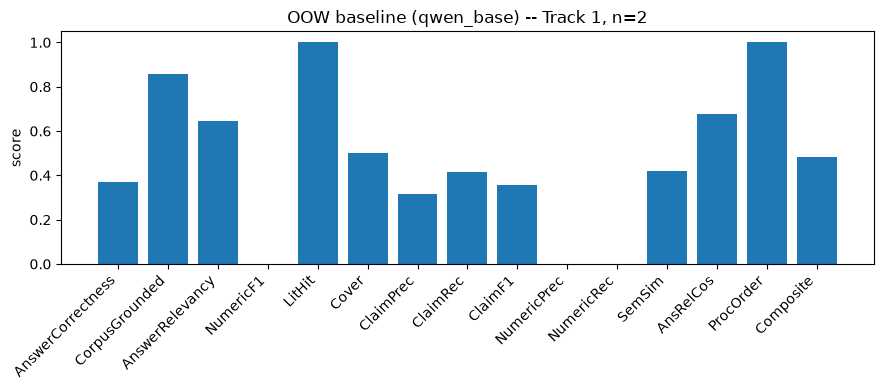

In [26]:
import matplotlib.pyplot as plt

# Reuses the summary loaded/printed by the cell above (re-run that cell first
# if you're executing this one in isolation).
means = {k: v for k, v in oow_qwen_base_summary["means"].items() if v is not None}
plt.figure(figsize=(9, 4))
plt.bar(means.keys(), means.values())
plt.title(f"OOW baseline (qwen_base) -- Track 1, n={oow_qwen_base_summary['n']}")
plt.ylabel("score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## § 11 — Prompt ablation: RAG/CoT-in-the-prompt vs. plain base (before any fine-tuning)

Before spending GPU time on fine-tuning, check how much of the available Track 1 knowledge can be
captured just by **prompting** the base model with retrieved context and/or a chain-of-thought
instruction -- no weights touched. Same V0-V4 design as VHF's own § 11 ablation
(`pipeline/eval/prep_ablation.py` / `run_ablation.py` / `score_ablation.py`, domain-parametrized
via `AgentPaths.from_env()` exactly like the rest of the pipeline):

- **v0_base** — plain question, no context, no reasoning instruction (same as the § 10 baseline).
- **v1_rag** — the top-k retrieved RAG chunks (built in § 3) injected as context.
- **v2_cot** — a chain-of-thought instruction, no retrieved context.
- **v3_rag_cot** — both together.
- **v4_pg** — a "Procedure guidance" block rendered from the Procedural Graph (§ 8) in the prompt;
  questions without a renderable path fall back to the v0 prompt at run time.

**Scoring uses the claim-level RAGAS suite v2** (see VHF notebook § 9 for the full metric table):
the RAG configs get real RAGAS Faithfulness + ContextPrecision/ContextRecall (contexts recovered from
`ablation_prompts.json`), the closed-book configs get CorpusGrounded; AnswerCorrectness (claim F1 vs
§ 7's `gold_claims`), AnswerRelevancy, role-aware NumericF1, LitHit, Cover and ProcOrder (reported,
not in the composite) apply everywhere. Composite weights are fixed per config kind and the summary
includes paired-bootstrap 95% CIs of each config vs v0_base. Requires § 7's
`colreg_qa_500_normalised_claims.json` — pass it via `--gold-file`; `--legacy` reproduces the old v1
metrics for comparison with historical numbers.

For VHF, this ordering turned out to matter a lot: v3_rag_cot (0.511) beat both the plain base (0.476)
**and** every fine-tuned checkpoint tried so far (0.24-0.31, before the `assistant_only_loss` fix) --
strong evidence that the underlying knowledge is genuinely useful, and that problems seen after
fine-tuning are about *how* that knowledge gets baked into weights, not whether the knowledge itself
is any good. Running this for OOW before committing to § 13 gives the same sanity check here.
(Historical note: the n=40 COLREG-only ablation preserved in `ablation_*_colreg_only_n40.*` was scored
with the old `legacy_v1` suite — don't compare those numbers against `ragas_v2.0` summaries.)


In [27]:
# SMOKE_TEST -> SMOKE_N questions x 4-5 configs, written to *_smoke files; full run -> all 500
# in the regular ablation_* files. ablation_tag_args() keeps the two from ever mixing.
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.prep_ablation",
    "--gold-file", str(NORM_FILE),
] + n_arg(500) + ablation_tag_args(), cwd=W)


0

In [28]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.run_ablation"]
                      + ablation_tag_args(), cwd=W)


0

In [29]:
# New-suite scoring needs the gold_claims sibling of the OOW gold file (§12.9).
_ablation_args = ablation_tag_args()
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.score_ablation",
                       "--gold-file", str(NORM_FILE)] + _ablation_args, cwd=W)

import json
_ablation_suffix = "_smoke" if SMOKE_TEST else ""
summary = json.loads((paths.cache_dir / f"ablation_summary{_ablation_suffix}.json").read_text())
print(f"metric_suite: {summary.get('_meta', {}).get('metric_suite', 'legacy_v1')}")
for cfg, means in summary.items():
    if cfg == "_meta":
        continue
    # Only the scalar metric means go into the scoreboard -- Composite_vs_v0_base is a
    # {delta, ci_lo, ci_hi, significant} dict (printed separately below), not a metric value.
    record("track1", cfg, {k: v for k, v in means.items() if not isinstance(v, dict)})
    ci = means.get("Composite_vs_v0_base")
    if ci:
        print(f"  {cfg:<12} Δvs_v0={ci['delta']:+.3f} [{ci['ci_lo']:+.3f},{ci['ci_hi']:+.3f}]"
              f"{' *' if ci.get('significant') else ' (noise)'}")
print_scoreboard("track1", baseline="v0_base")


metric_suite: ragas_v2.0
  v1_rag       Δvs_v0=+0.196 [+0.133,+0.258] *
  v2_cot       Δvs_v0=+0.153 [+0.058,+0.248] *
  v3_rag_cot   Δvs_v0=+0.230 [+0.103,+0.357] *
  v4_pg        Δvs_v0=+0.103 [-0.006,+0.212] (noise)

=== scoreboard: track1 ===
label                 AnswerCorrectness CorpusGrounded AnswerRelevancy NumericF1   LitHit    Cover ClaimPrec ClaimRec  ClaimF1 NumericPrec NumericRec   SemSim AnsRelCos ProcOrder Composite latency_mean_s latency_p50_s ContextPrecision ContextRecall Faithfulness     Δbase
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
oow_qwen_base_smoke               0.371          0.857           0.644     0.000    1.000    0.500     0.315    0.416    0.356       0.000      0.000    0.418     0.679     1.000     0.482              —      

---
## § 12 — Data-coverage gap analysis (reuse, no changes needed)

`pipeline/eval/analyze_gaps.py` is domain-agnostic by design (no VHF/COLREG field names hardcoded) --
point it at the baseline eval file from § 10, grouped by `section_id` (here, COLREG rule reference).


In [30]:
result = subprocess.run(
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.analyze_gaps",
     "--eval-file", str(CACHE / f"eval_{smoke_tag('oow_qwen_base')}.jsonl"),
     "--group-by", "section_id"],
    cwd=W, capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Loaded 2 rows from C:\Users\jcsch\Documents\Python\Auto Pilot\Data\OOW\OOW_Agents_Training\eval_oow_qwen_base_smoke.jsonl
DATA-COVERAGE GAP ANALYSIS  â€”  grouped by 'section_id'  (2 rows across 1 groups)

Group                                            n  MeanComposite
Rule 1                                           2          0.482

WORST 1 GROUPS â€” likely data-coverage gaps, worst first

--- Rule 1  (mean Composite=0.482, n=2) ---
  Dominant failure metric(s): {'Cover': 1, 'NumericF1': 1}

  Q: To what waters do the COLREGs apply?
  Gold: To all vessels upon the high seas and in all waters connected therewith navigable by seagoing vessels.
  A: The COLREGs (International Regulations for Preventing Collisions at Sea) apply to all sea areas except where specifically excluded by paragraph 3 of Article III of the Convention on the International Regulations for Preventing Collisions at Sea, 1972. This means they apply to all waters connected wi
  metrics: {'SemSim': 0.404, 'AnsRelCos

---
## § 12.1 — Cross-source consistency check (framework reuse; fact-list is a TODO)

`pipeline/eval/check_consistency.py`'s *mechanism* (quote-scoped regex checks over every parsed JSON
section) is reusable, but its actual fact lists (`PHONETIC_ALPHABET`, `REPEAT_PROWORDS`,
`NUMBER_WORDS`) are VHF-specific and don't apply to COLREG text -- so this will currently report **zero
findings** for OOW, which is expected, not a sign everything is consistent. A COLREG-appropriate
Level-1 fact list (e.g. rule-number ↔ rule-title cross-references, light/shape/sound-signal
specifications that have exactly one correct answer) is a follow-up, not required before § 13.


In [31]:
result = subprocess.run(
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.check_consistency"],
    cwd=W, capture_output=True, text=True,
)
print(result.stdout[-3000:])
if result.returncode != 0:
    print(result.stderr)

CROSS-SOURCE CONSISTENCY CHECK (Level 1)  â€”  5 finding(s)

--- phonetic_variant  Â·  usa/marine_reports/2024/MIR2401.pdf  Â·  section incident_mir2401_oow_7505e8bd_analysis (Analysis / conclusions excerpt) ---
  ITU/NATO standard spelling is "BRAVO", not "Beta"
  snippet: ...pipeline controller and nightshift pipeline controller. 16. Beta Offshore was not in compliance with regulations when the co...

--- phonetic_variant  Â·  usa/marine_reports/2024/MIR2401.pdf  Â·  section incident_mir2401_oow_7505e8bd_analysis (Analysis / conclusions excerpt) ---
  ITU/NATO standard spelling is "BRAVO", not "Beta"
  snippet: ...st the pipeline controllers following the accident. 17. Had Beta Offshore implemented a pipeline safety management system, t...

--- phonetic_variant  Â·  usa/marine_reports/2024/MIR2401.pdf  Â·  section incident_mir2401_oow_7505e8bd_analysis (Analysis / conclusions excerpt) ---
  ITU/NATO standard spelling is "BRAVO", not "Beta"
  snippet: ...later. Contributing to the amo

---
## § 13 · Fine-tuning OOW-QWEN (3 stages)

Identical stages/hyperparameters to VHF -- `train_sft.py` → `train_dpo.py` → `train_reflection.py`,
each domain-aware via `AgentPaths.from_env()` and saving to
`_models/OOW/oow_qwen_{sft,dpo,reflect}_lora/`. `SFT_DATASETS`/`DPO_FILES`/`REFL_FILES` in those three
scripts are keyed by `paths.domain`, so OOW's file lists (rule-text Track 1 from § 6 + real-incident
excerpts from § 6.1 + PG step-order data from § 8) are picked up automatically -- no CLI flags needed.
DPO pairs now include the 6th perturbation axis `swap_step_order` (§ 8). Cross-track multi-hop
(rule text <-> incident) is already folded into `oow_multihop.jsonl` from § 6. Track 2
(applied helm/engine-order decisions, § 6.5) is still not built, so this trains COLREG
rules/knowledge + real-incident reasoning only, until Track 2 data exists and is added to each
script's file list.

Stage 1 — SFT. Adapter ~50 MB.


In [ ]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.train_sft"], cwd=W)

Stage 2 — DPO. Adapter ~25 MB.

In [ ]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.train_dpo"], cwd=W)

Stage 3 — Reflection. Adapter ~25 MB.

In [ ]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.train_reflection"], cwd=W)

---
## § 13.1 · Merge → OOW-QWEN (single deployable model)


In [ ]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.train.merge_adapter"], cwd=W)

---
## § 13.2 · Evaluate OOW-QWEN on the 500 held-out COLREG Q&A (Track 1)

Closed-book (no prompt tricks) — measures what the fine-tune internalized. Scored with the claim-level
RAGAS suite v2 (AnswerCorrectness, CorpusGrounded, AnswerRelevancy, NumericF1, LitHit, Cover, fixed-weight
Composite — see VHF notebook § 9 for definitions and why the old suite was replaced). Requires § 7's
`colreg_qa_500_normalised_claims.json`; `--legacy` reproduces the old metrics. Summaries are stamped with
`metric_suite` — never compare `ragas_v2.0` numbers against `legacy_v1` numbers.


In [ ]:
_tag = smoke_tag("oow_qwen")
oow_qwen_summary = ensure_and_record(
    "track1", _tag,
    CACHE / f"eval_{_tag}_summary.json",
    [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_finetuned",
     "--model", str(paths.domain_models_dir / "OOW-QWEN"), "--tag", _tag,
     "--gold-file", str(NORM_FILE), "--force-4bit"] + n_arg(500),
    baseline=smoke_tag("oow_qwen_base"),
)


---
## § 13.3 · Stage-attribution probes — did DPO and Reflection actually do their jobs?

Aggregate eval deltas can't say WHICH training stage helped. [probe_dpo.py](pipeline/eval/probe_dpo.py)
measures each stage's job directly, on a deterministic **held-out** probe set built from the gold file
(cached in `probe_set.json`). See VHF notebook § 13.4 for the full explanation of the DPO probe
(per-axis log-likelihood win-rate, including `swap_step_order`) and the reflection probe (Δ
AnswerCorrectness, revision − draft). Run once per checkpoint — GPU-bound, cloud pod or `--force-4bit`
locally.


In [ ]:
for model_path, raw_tag in [
    ("Qwen/Qwen2.5-7B-Instruct", "oow_qwen_base"),
    (str(paths.domain_models_dir / "OOW-QWEN"), "oow_qwen"),
]:
    tag = smoke_tag(raw_tag)
    out = CACHE / f"probe_{tag}.json"
    if out.exists():
        print(f"[skip] {out.name} already exists -- not recomputing.")
    else:
        subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.probe_dpo",
                               "--model", model_path, "--tag", tag,
                               "--gold-file", str(NORM_FILE), "--force-4bit"]
                              + probe_smoke_args(), cwd=W)
    record_probe(tag, out)


---
## § 14 · Compression 1 — AWQ int4 quantization


In [ ]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.compress.compress_quantize_awq"], cwd=W)

---
## § 14.1 · Compression 2 — Layer pruning (ShortGPT-style)


In [ ]:
subprocess.check_call([
    sys.executable, "-u", "-X", "utf8", "-m", "pipeline.compress.compress_prune", "--n-prune", "4",
], cwd=W)

---
## § 14.2 · Compression 3 — Knowledge Distillation → DistillOOW-QWEN


In [ ]:
subprocess.check_call([sys.executable, "-u", "-X", "utf8", "-m", "pipeline.compress.compress_distill"], cwd=W)

---
## § 15 · Final comparison — all model tags, Track 1

Backfill eval for the AWQ/pruned/distilled tags, then compare everything side by side (same shape as
VHF's § 15 comparison table).


In [ ]:
tags_and_models = [
    ("oow_qwen_awq",      paths.domain_models_dir / "OOW-QWEN-awq-int4"),
    ("oow_qwen_pruned",   paths.domain_models_dir / "OOW-QWEN-pruned"),
    ("distill_oow_qwen",  paths.domain_models_dir / "DistillOOW-QWEN"),
]
for raw_tag, model_dir in tags_and_models:
    if not model_dir.exists():
        print(f"  (skipping {raw_tag} -- {model_dir} not found)")
        continue
    tag = smoke_tag(raw_tag)
    ensure_and_record(
        "track1", tag,
        CACHE / f"eval_{tag}_summary.json",
        [sys.executable, "-u", "-X", "utf8", "-m", "pipeline.eval.eval_finetuned",
         "--model", str(model_dir), "--tag", tag, "--gold-file", str(NORM_FILE), "--force-4bit"] + n_arg(500),
        baseline=smoke_tag("oow_qwen_base"),
    )


In [ ]:
import json
import pandas as pd

rows = []
for raw_tag in ["oow_qwen_base", "oow_qwen", "oow_qwen_awq", "oow_qwen_pruned", "distill_oow_qwen"]:
    tag = smoke_tag(raw_tag)
    p = paths.cache_dir / f"eval_{tag}_summary.json"
    if not p.exists():
        continue
    s = json.loads(p.read_text())
    row = {"tag": tag, "n": s["n"], **s["means"]}
    if s.get("latency", {}).get("mean_s") is not None:
        row["latency_mean_s"] = s["latency"]["mean_s"]
    rows.append(row)

pd.set_option("display.width", 140)
print(pd.DataFrame(rows).to_string(index=False))
